# Module 5 - 3-Axis Attitude Feedback Control

In Module 4, we developed the dynamics of variable-speed control moment gyroscopes (VSCMGs) from first principles and obtained the coupled spacecraft-device equations of motion. This formulation also provided a common framework for understanding reaction wheels (RWs) and conventional control moment gyroscopes (CMGs) as constrained cases of the more general VSCMG model.

In this module, we move from **modeling the momentum exchange devices to actively controlling the spacecraft with them**. Using the equations of motion developed previously, we will study how a cluster of momentum exchange devices can generate the internal torques required for three-axis attitude feedback control.

The module will introduce the control architecture required to translate a desired spacecraft control torque into commands for the momentum exchange devices. In particular, we will examine VSCMG and CMG null motion and singularity avoidance, develop the VSCMG inner servo and outer attitude-control loops, and then consider corresponding feedback-control strategies for reaction-wheel speed and motor torque.

By the end of the module, the objective is to connect the complete control chain

$$
\text{attitude error}
\rightarrow
\text{spacecraft control torque}
\rightarrow
\text{momentum-device commands}
\rightarrow
\text{spacecraft response}.
$$

> **Prior material:**  
> [Specialization 1, Course 2 - Momentum Exchange Devices Slides](https://github.com/johnm3398/Spacecraft-Dynamics-and-Control/blob/main/01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf)

---

In [1]:
import numpy as np

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, r"../../")
import AttitudeKinematicsLib as ak

# Reusable Attitude Dynamics Framework

## `rk4_step` - Numerical Integrator

In [2]:
def rk4_step(f, t, x, dt, *args, **kwargs):
    """
    Advance one timestep using classical 4th-order Runge–Kutta (RK4).
    
    Parameters
    ----------
    f : callable
        RHS function with signature f(t, x, *args, **kwargs) -> xdot.
    t : float
        Current time.
    x : np.ndarray
        Current state vector.
    dt : float
        Timestep size.
    *args, **kwargs
        Extra arguments passed through to `f`.
    
    Returns
    -------
    x_next : np.ndarray
        State advanced by one RK4 step of size `dt`.
    """
    k1 = f(t, x, *args, **kwargs)
    k2 = f(t + 0.5*dt, x + 0.5*dt*k1, *args, **kwargs)
    k3 = f(t + 0.5*dt, x + 0.5*dt*k2, *args, **kwargs)
    k4 = f(t + dt, x + dt*k3, *args, **kwargs)
    
    x_next = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    
    return x_next

## `MomentumExchangeDevice` dataclass definition

In [3]:
from dataclasses import dataclass
from typing import Literal


@dataclass
class MomentumExchangeDevice:
    """
    Define the fixed physical properties, mounting, and hardware limits
    of a momentum exchange device.

    Parameters
    ----------
    mode : {"RW", "CMG", "VSCMG"}
        Momentum exchange device type.
    J : tuple[float, float, float] or None
        Combined MED principal inertias (J_s, J_t, J_g) expressed in
        the device frame [kg*m^2], where J = I_G + I_W.

        May be None for a reduced reaction-wheel model when the fixed
        non-spin device inertia is already incorporated into the
        supplied spacecraft inertia.
    I_Ws : float
        Wheel spin-axis moment of inertia [kg*m^2].
    C_BG_ref : np.ndarray
        Reference device-frame orientation relative to the spacecraft
        body frame at gamma = 0. Its columns are
        (g_s_ref_B, g_t_ref_B, g_g_B).
    Omega_bounds : tuple[float, float], optional
        Lower and upper wheel spin-rate limits [rad/s].
    u_s_bounds : tuple[float, float], optional
        Lower and upper wheel motor torque limits [N*m].
    gamma_bounds : tuple[float, float], optional
        Lower and upper gimbal-angle limits [rad].
    gamma_dot_bounds : tuple[float, float], optional
        Lower and upper gimbal-rate limits [rad/s].
    u_g_bounds : tuple[float, float], optional
        Lower and upper gimbal motor torque limits [N*m].

    Notes
    -----
    The present dynamics model stores the minimum inertia quantities
    required by the course equations: the combined device inertia J
    and the wheel spin-axis inertia I_Ws.

    A higher-fidelity hardware model could instead accept separate
    gimbal and wheel inertia tensors I_G and I_W, then derive
    J = I_G + I_W and I_Ws from those component properties.
    """

    mode: Literal["RW", "CMG", "VSCMG"]
    J: tuple[float, float, float] | None
    I_Ws: float
    C_BG_ref: np.ndarray

    Omega_bounds: tuple[float, float] | None = None
    u_s_bounds: tuple[float, float] | None = None
    gamma_bounds: tuple[float, float] | None = None
    gamma_dot_bounds: tuple[float, float] | None = None
    u_g_bounds: tuple[float, float] | None = None

    def __post_init__(self):
        if self.mode not in ("RW", "CMG", "VSCMG"):
            raise ValueError("mode must be 'RW', 'CMG', or 'VSCMG'.")

        self.I_Ws = float(self.I_Ws)
        self.C_BG_ref = np.asarray(self.C_BG_ref, dtype=float)

        if self.I_Ws <= 0.0:
            raise ValueError("I_Ws must be positive.")

        if self.C_BG_ref.shape != (3, 3):
            raise ValueError("C_BG_ref must be a 3x3 DCM.")

        if not np.allclose(self.C_BG_ref.T @ self.C_BG_ref, np.eye(3)):
            raise ValueError("C_BG_ref must be orthogonal.")

        if not np.isclose(np.linalg.det(self.C_BG_ref), 1.0):
            raise ValueError("C_BG_ref must be a proper rotation matrix.")

        if self.J is not None:
            if len(self.J) != 3:
                raise ValueError("J must contain (J_s, J_t, J_g).")

            J_s, J_t, J_g = self.J

            self.J = (
                float(J_s),
                float(J_t),
                float(J_g)
            )

            if any(J_i <= 0.0 for J_i in self.J):
                raise ValueError("All principal inertias in J must be positive.")

        if self.mode in ("CMG", "VSCMG") and self.J is None:
            raise ValueError(f"{self.mode} requires J.")

        self.Omega_bounds = self._validate_bounds(self.Omega_bounds, "Omega_bounds")
        self.u_s_bounds = self._validate_bounds(self.u_s_bounds, "u_s_bounds")
        self.gamma_bounds = self._validate_bounds(self.gamma_bounds, "gamma_bounds")
        self.gamma_dot_bounds = self._validate_bounds(self.gamma_dot_bounds, "gamma_dot_bounds")
        self.u_g_bounds = self._validate_bounds(self.u_g_bounds, "u_g_bounds")

    @classmethod
    def rw(cls, I_Ws, C_BG_ref, J=None, Omega_bounds=None, u_s_bounds=None,
           gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a reaction wheel.
        """
        device = cls(
            mode="RW",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @classmethod
    def cmg(cls, J, I_Ws, C_BG_ref, Omega_bounds=None, u_s_bounds=None,
            gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a control moment gyroscope.
        """
        device = cls(
            mode="CMG",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @classmethod
    def vscmg(cls, J, I_Ws, C_BG_ref, Omega_bounds=None, u_s_bounds=None,
              gamma_bounds=None, gamma_dot_bounds=None, u_g_bounds=None):
        """
        Construct a variable-speed control moment gyroscope.
        """
        device = cls(
            mode="VSCMG",
            J=J,
            I_Ws=I_Ws,
            C_BG_ref=C_BG_ref,
            Omega_bounds=Omega_bounds,
            u_s_bounds=u_s_bounds,
            gamma_bounds=gamma_bounds,
            gamma_dot_bounds=gamma_dot_bounds,
            u_g_bounds=u_g_bounds
        )
        return device

    @staticmethod
    def _validate_bounds(
        bounds: tuple[float, float] | None,
        name: str
    ) -> tuple[float, float] | None:
        """
        Validate an optional (lower, upper) hardware bound pair.
        """
        if bounds is None:
            validated_bounds = None
            return validated_bounds

        if len(bounds) != 2:
            raise ValueError(f"{name} must contain (lower, upper).")

        lower = float(bounds[0])
        upper = float(bounds[1])

        if lower >= upper:
            raise ValueError(f"{name} must satisfy lower < upper.")

        validated_bounds = (lower, upper)

        return validated_bounds

    @property
    def is_rw(self):
        is_rw = self.mode == "RW"
        return is_rw

    @property
    def is_cmg(self):
        is_cmg = self.mode == "CMG"
        return is_cmg

    @property
    def is_vscmg(self):
        is_vscmg = self.mode == "VSCMG"
        return is_vscmg

    @property
    def has_combined_inertia(self):
        has_combined_inertia = self.J is not None
        return has_combined_inertia

    @property
    def J_s(self):
        J = self._require_combined_inertia()
        J_s = J[0]
        return J_s

    @property
    def J_t(self):
        J = self._require_combined_inertia()
        J_t = J[1]
        return J_t

    @property
    def J_g(self):
        J = self._require_combined_inertia()
        J_g = J[2]
        return J_g

    @property
    def g_s_ref_B(self):
        g_s_ref_B = self.C_BG_ref[:, 0]
        return g_s_ref_B

    @property
    def g_t_ref_B(self):
        g_t_ref_B = self.C_BG_ref[:, 1]
        return g_t_ref_B

    @property
    def g_g_B(self):
        g_g_B = self.C_BG_ref[:, 2]
        return g_g_B

    def _require_combined_inertia(self) -> tuple[float, float, float]:
        """
        Return the combined MED principal inertia tuple when available.
        """
        if self.J is None:
            raise ValueError("Combined device inertia J was not supplied.")
        J = self.J
        return J

    def axes_B(self, gamma):
        """
        Return the instantaneous device axes expressed in B.

        Parameters
        ----------
        gamma : float
            Current gimbal angle measured from the reference
            orientation [rad].

        Returns
        -------
        g_s_B : np.ndarray
            Current spin axis expressed in B.
        g_t_B : np.ndarray
            Current transverse axis expressed in B.
        g_g_B : np.ndarray
            Gimbal axis expressed in B.
        """
        g_s_B =  np.cos(gamma)*self.g_s_ref_B + np.sin(gamma)*self.g_t_ref_B
        g_t_B = -np.sin(gamma)*self.g_s_ref_B + np.cos(gamma)*self.g_t_ref_B
        g_g_B = self.g_g_B
        return g_s_B, g_t_B, g_g_B

    def C_BG(self, gamma):
        """
        Return the instantaneous device-frame DCM relative to B.
        """
        g_s_B, g_t_B, g_g_B = self.axes_B(gamma)
        C_BG = np.column_stack((g_s_B, g_t_B, g_g_B))
        return C_BG

    def inertia_B(self, gamma):
        """
        Return the combined MED inertia expressed in B.

        Requires the combined principal inertia tuple J.
        """
        J = self._require_combined_inertia()
        C_BG = self.C_BG(gamma)
        J_matrix = np.diag(J)
        J_B = C_BG @ J_matrix @ C_BG.T
        return J_B

## `pack_state` & `unpack_state`

In [4]:
def pack_state(sigma_BN, omega_BN_B, gamma, gamma_dot, Omega):
    """
    Pack the spacecraft and momentum-device states into a single state vector.

    Parameters
    ----------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].

    Returns
    -------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    """
    sigma_BN   = np.asarray(sigma_BN, dtype=float)
    omega_BN_B = np.asarray(omega_BN_B, dtype=float)
    gamma      = np.atleast_1d(np.asarray(gamma, dtype=float))
    gamma_dot  = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
    Omega      = np.atleast_1d(np.asarray(Omega, dtype=float))

    if sigma_BN.shape != (3,):
        raise ValueError("sigma_BN must contain three elements.")

    if omega_BN_B.shape != (3,):
        raise ValueError("omega_BN_B must contain three elements.")

    if not (gamma.size == gamma_dot.size == Omega.size):
        raise ValueError("gamma, gamma_dot, and Omega must have equal length.")

    x = np.hstack((sigma_BN, omega_BN_B, gamma, gamma_dot, Omega))
    return x

In [5]:
def unpack_state(x, N):
    """
    Unpack the spacecraft and momentum-device state vector.

    Parameters
    ----------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    N : int
        Number of momentum exchange devices represented in the state.

    Returns
    -------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise ValueError("x must be a one-dimensional state vector.")

    if x.size != 6 + 3*N:
        raise ValueError(f"x must contain {6 + 3*N} elements for N = {N}.")

    sigma_BN   = x[0:3]
    omega_BN_B = x[3:6]
    gamma      = x[6:6 + N]
    gamma_dot  = x[6 + N:6 + 2*N]
    Omega      = x[6 + 2*N:6 + 3*N]

    return sigma_BN, omega_BN_B, gamma, gamma_dot, Omega

## `SpacecraftAttitudeDynamicsModel` Class definition

> **Implementation note:**  
> For Module 5, the reusable attitude dynamics framework is extended slightly to support closed-loop control analysis.
>
> `SpacecraftAttitudeDynamicsModel.state_derivative()` now accepts an `input_function` returning $(L_B, u_s, u_g, L_r)$, although only $L_B$, $u_s$, and $u_g$ are used by the plant dynamics. The requested control torque $L_r$ is ignored by the dynamics model itselftion.

In [6]:
class SpacecraftAttitudeDynamicsModel:
    """
    Model the coupled rotational dynamics of a spacecraft and its
    momentum exchange devices.

    Parameters
    ----------
    I_s_B : np.ndarray
        Baseline spacecraft inertia expressed in B [kg*m^2].

        For devices with an explicitly modelled combined inertia J,
        I_s_B represents the spacecraft hub inertia and the device
        inertias are added internally.

        For a reduced RW with J=None, I_s_B must already include that
        wheel's fixed non-spin inertia, as in the I_RW formulation.
    devices : list[MomentumExchangeDevice]
        Momentum exchange devices mounted to the spacecraft.

    Notes
    -----
    Devices with J=(J_s, J_t, J_g) use the full MED formulation.

    A reaction wheel may instead use J=None when its fixed non-spin
    inertia is already incorporated into I_s_B. In this reduced RW
    formulation, the spin-axis dynamics remain explicitly modelled
    using I_Ws.
    """

    def __init__(self, I_s_B, devices):
        self.I_s_B = np.asarray(I_s_B, dtype=float)
        self.devices = list(devices)

        if self.I_s_B.shape != (3, 3):
            raise ValueError("I_s_B must be a 3x3 inertia tensor.")

        if not np.allclose(self.I_s_B, self.I_s_B.T):
            raise ValueError("I_s_B must be symmetric.")

        if np.any(np.linalg.eigvalsh(self.I_s_B) <= 0.0):
            raise ValueError("I_s_B must be positive definite.")

        if not all(isinstance(device, MomentumExchangeDevice) for device in self.devices):
            raise TypeError("All devices must be MomentumExchangeDevice objects.")

    @property
    def num_devices(self) -> int:
        """Return the number of momentum exchange devices."""
        num_devices = len(self.devices)
        return num_devices

    def inertia_B(self, gamma) -> np.ndarray:
        """
        Compute the instantaneous inertia tensor used by the EOM.

        Parameters
        ----------
        gamma : np.ndarray
            Gimbal angle of each momentum exchange device [rad].

        Returns
        -------
        I_B : np.ndarray
            Instantaneous spacecraft-device inertia tensor [kg*m^2].
        """
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))

        if gamma.size != self.num_devices:
            raise ValueError("gamma must contain one value per device.")

        I_B = self.I_s_B.copy()

        for device, gamma_i in zip(self.devices, gamma):
            if device.has_combined_inertia:
                I_B += device.inertia_B(gamma_i)

        return I_B

    def solve_coupled_eom(
        self,
        omega_BN_B,
        gamma,
        gamma_dot,
        Omega,
        L_B=None,
        u_s=None,
        u_g=None
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Solve the coupled spacecraft and MED equations of motion.

        Parameters
        ----------
        omega_BN_B : np.ndarray
            Spacecraft angular velocity expressed in B [rad/s].
        gamma : np.ndarray
            Device gimbal angles [rad].
        gamma_dot : np.ndarray
            Device gimbal rates [rad/s].
        Omega : np.ndarray
            Device wheel speeds [rad/s].
        L_B : np.ndarray, optional
            External torque expressed in B [N*m].
        u_s : np.ndarray, optional
            Wheel motor torques [N*m].
        u_g : np.ndarray, optional
            Gimbal motor torques [N*m].

        Returns
        -------
        omega_dot_B : np.ndarray
            Spacecraft angular acceleration expressed in B [rad/s^2].
        Omega_dot : np.ndarray
            Device wheel accelerations [rad/s^2].
        gamma_ddot : np.ndarray
            Device gimbal accelerations [rad/s^2].
        """
        N = self.num_devices

        omega_BN_B = np.asarray(omega_BN_B, dtype=float)
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))
        gamma_dot = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
        Omega = np.atleast_1d(np.asarray(Omega, dtype=float))

        if omega_BN_B.shape != (3,):
            raise ValueError("omega_BN_B must contain three elements.")

        if not (gamma.size == gamma_dot.size == Omega.size == N):
            raise ValueError("gamma, gamma_dot, and Omega must contain one value per device.")

        L_B = (
            np.zeros(3)
            if L_B is None
            else np.asarray(L_B, dtype=float)
        )

        u_s = (
            np.zeros(N)
            if u_s is None
            else np.atleast_1d(np.asarray(u_s, dtype=float))
        )

        u_g = (
            np.zeros(N)
            if u_g is None
            else np.atleast_1d(np.asarray(u_g, dtype=float))
        )

        if L_B.shape != (3,):
            raise ValueError("L_B must contain three elements.")

        if u_s.size != N or u_g.size != N:
            raise ValueError("u_s and u_g must contain one value per device.")

        I_B = self.inertia_B(gamma)

        # Current MED geometry and projected spacecraft rates
        G_s = np.zeros((3, N))
        G_t = np.zeros((3, N))
        G_g = np.zeros((3, N))

        J_s = np.zeros(N)
        J_t = np.zeros(N)
        J_g = np.zeros(N)
        I_Ws = np.zeros(N)

        omega_s = np.zeros(N)
        omega_t = np.zeros(N)
        omega_g = np.zeros(N)

        for i, device in enumerate(self.devices):
            g_s_B, g_t_B, g_g_B = device.axes_B(gamma[i])

            G_s[:, i] = g_s_B
            G_t[:, i] = g_t_B
            G_g[:, i] = g_g_B

            I_Ws[i] = device.I_Ws

            if device.has_combined_inertia:
                J_s[i] = device.J_s
                J_t[i] = device.J_t
                J_g[i] = device.J_g

            omega_s[i] = g_s_B @ omega_BN_B
            omega_t[i] = g_t_B @ omega_BN_B
            omega_g[i] = g_g_B @ omega_BN_B

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(f"RW device {i} requires gamma_dot = 0.")

        # Coupled system:
        #
        #     M @ a = b
        #
        # where
        #
        #     a = [omega_dot_B, Omega_dot, gamma_ddot]
        #
        M = np.zeros((3 + 2*N, 3 + 2*N))
        b = np.zeros(3 + 2*N)

        # Spacecraft rotational EOM
        M[0:3, 0:3] = I_B

        b_B = (
            -np.cross(
                omega_BN_B,
                I_B @ omega_BN_B
            )
            + L_B
        )

        for i, device in enumerate(self.devices):
            i_Omega = 3 + i
            i_gamma = 3 + N + i

            wheel_row = 3 + i
            gimbal_row = 3 + N + i

            g_s_B = G_s[:, i]
            g_t_B = G_t[:, i]
            g_g_B = G_g[:, i]

            if device.has_combined_inertia:
                # Full MED contribution to spacecraft EOM,
                # w.r.t. single-VSCMG EOM on slide 27
                M[0:3, i_Omega] = I_Ws[i]*g_s_B
                M[0:3, i_gamma] = J_g[i]*g_g_B

                b_s_i = (
                    g_s_B
                    * (J_s[i] - J_t[i] + J_g[i])
                    * gamma_dot[i]
                    * omega_t[i]
                )

                b_t_i = g_t_B*(
                    (
                        (J_s[i] - J_t[i] - J_g[i])*omega_s[i]
                        + I_Ws[i]*Omega[i]
                    )*gamma_dot[i]
                    + I_Ws[i]*Omega[i]*omega_g[i]
                )

                b_g_i = (
                    g_g_B
                    * I_Ws[i]
                    * Omega[i]
                    * omega_t[i]
                )

                b_B += -b_s_i - b_t_i + b_g_i

            else:
                # Reduced RW formulation.
                #
                # I_s_B already contains the fixed non-spin RW inertia,
                # while the spin-axis momentum remains explicit.
                h_s_i = (
                    I_Ws[i]
                    * (omega_s[i] + Omega[i])
                )

                b_B -= np.cross(
                    omega_BN_B,
                    h_s_i*g_s_B
                )

                b_B -= u_s[i]*g_s_B

            # Wheel dynamics / CMG fixed-speed constraint
            if device.is_cmg:
                M[wheel_row, i_Omega] = 1.0
                b[wheel_row] = 0.0

            else:
                M[wheel_row, 0:3] = I_Ws[i]*g_s_B
                M[wheel_row, i_Omega] = I_Ws[i]

                b[wheel_row] = (
                    u_s[i]
                    - I_Ws[i]
                    * gamma_dot[i]
                    * omega_t[i]
                )

            # Gimbal dynamics / RW locked-gimbal constraint
            if device.is_rw:
                M[gimbal_row, i_gamma] = 1.0
                b[gimbal_row] = 0.0

            else:
                M[gimbal_row, 0:3] = J_g[i]*g_g_B
                M[gimbal_row, i_gamma] = J_g[i]

                b[gimbal_row] = (
                    u_g[i]
                    + (J_s[i] - J_t[i])
                    * omega_s[i]
                    * omega_t[i]
                    + I_Ws[i]
                    * Omega[i]
                    * omega_t[i]
                )

        b[0:3] = b_B

        a = np.linalg.solve(M, b)

        omega_dot_B = a[0:3]
        Omega_dot = a[3:3 + N]
        gamma_ddot = a[3 + N:3 + 2*N]

        return omega_dot_B, Omega_dot, gamma_ddot

    def state_derivative(
        self,
        t,
        x,
        input_function=None
    ) -> np.ndarray:
        """
        Evaluate the complete state derivative.

        Parameters
        ----------
        t : float
            Current simulation time [s].
        x : np.ndarray
            Spacecraft and momentum-device state vector.
        input_function : callable, optional
            Function with signature input_function(t, x) returning
            (L_B, u_s, u_g, L_r, sigma_BR, omega_BR_B).

        Returns
        -------
        x_dot : np.ndarray
            State derivative corresponding to x.
        """
        N = self.num_devices

        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        if input_function is None:
            L_B = np.zeros(3)
            u_s = np.zeros(N)
            u_g = np.zeros(N)

        else:
            L_B, u_s, u_g, _, _, _ = input_function(t, x)

        sigma_dot_BN = 0.25 * ak.Bmat_MRP(sigma_BN) @ omega_BN_B

        omega_dot_B, Omega_dot, gamma_ddot = self.solve_coupled_eom(
            omega_BN_B,
            gamma,
            gamma_dot,
            Omega,
            L_B=L_B,
            u_s=u_s,
            u_g=u_g
        )

        x_dot = np.hstack((
            sigma_dot_BN,
            omega_dot_B,
            gamma_dot,
            gamma_ddot,
            Omega_dot
        ))

        return x_dot

    def angular_momentum_B(self, x) -> np.ndarray:
        """
        Compute the total spacecraft-device angular momentum in B.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_B : np.ndarray
            Total angular momentum expressed in B [N*m*s].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        I_B = self.inertia_B(gamma)

        H_B = I_B @ omega_BN_B

        for i, device in enumerate(self.devices):
            g_s_B, _, g_g_B = device.axes_B(gamma[i])

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

            if device.has_combined_inertia:
                H_B += (
                    device.I_Ws
                    * Omega[i]
                    * g_s_B
                    + device.J_g
                    * gamma_dot[i]
                    * g_g_B
                )

            else:
                omega_s_i = g_s_B @ omega_BN_B

                h_s_i = (
                    device.I_Ws
                    * (omega_s_i + Omega[i])
                )

                H_B += h_s_i*g_s_B

        return H_B

    def angular_momentum_N(self, x) -> np.ndarray:
        """
        Compute the total spacecraft-device angular momentum in N.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_N : np.ndarray
            Total angular momentum expressed in N [N*m*s].
        """
        sigma_BN, _, _, _, _ = unpack_state(x, self.num_devices)

        H_B = self.angular_momentum_B(x)
        C_BN = ak.MRP_to_DCM(sigma_BN)

        H_N = C_BN.T @ H_B

        return H_N

    def kinetic_energy(self, x) -> float:
        """
        Compute the total rotational kinetic energy.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        T : float
            Total rotational kinetic energy [J].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        I_B = self.inertia_B(gamma)

        T = (
            0.5
            * omega_BN_B
            @ I_B
            @ omega_BN_B
        )

        for i, device in enumerate(self.devices):
            g_s_B, _, g_g_B = device.axes_B(gamma[i])

            omega_s_i = g_s_B @ omega_BN_B
            omega_g_i = g_g_B @ omega_BN_B

            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

            if device.has_combined_inertia:
                T += (
                    device.I_Ws
                    * Omega[i]
                    * omega_s_i
                    + 0.5
                    * device.I_Ws
                    * Omega[i]**2
                    + device.J_g
                    * gamma_dot[i]
                    * omega_g_i
                    + 0.5
                    * device.J_g
                    * gamma_dot[i]**2
                )

            else:
                T += (
                    0.5
                    * device.I_Ws
                    * (omega_s_i + Omega[i])**2
                )

        return float(T)

    def kinetic_energy_rate(
        self,
        x,
        L_B=None,
        u_s=None,
        u_g=None
    ) -> float:
        """
        Compute the instantaneous rotational kinetic-energy rate.

        For CMGs, the wheel speed is constrained to remain constant.
        The wheel-servo torque required to enforce that constraint is
        therefore recovered from the wheel dynamics.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.
        L_B : np.ndarray, optional
            External torque expressed in B [N*m].
        u_s : np.ndarray, optional
            Wheel motor torques [N*m].
        u_g : np.ndarray, optional
            Gimbal motor torques [N*m].

        Returns
        -------
        T_dot : float
            Instantaneous kinetic-energy rate [W].
        """
        N = self.num_devices

        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        L_B = (
            np.zeros(3)
            if L_B is None
            else np.asarray(L_B, dtype=float)
        )

        u_s = (
            np.zeros(N)
            if u_s is None
            else np.atleast_1d(
                np.asarray(u_s, dtype=float)
            )
        )

        u_g = (
            np.zeros(N)
            if u_g is None
            else np.atleast_1d(
                np.asarray(u_g, dtype=float)
            )
        )

        if L_B.shape != (3,):
            raise ValueError(
                "L_B must contain three elements."
            )

        if u_s.size != N or u_g.size != N:
            raise ValueError(
                "u_s and u_g must contain one value per device."
            )

        for i, device in enumerate(self.devices):
            if device.is_rw and not np.isclose(
                gamma_dot[i],
                0.0
            ):
                raise ValueError(
                    f"RW device {i} requires gamma_dot = 0."
                )

        u_s_actual = u_s.copy()

        # Recover the wheel-servo torque required to hold
        # Omega constant for each CMG.
        if any(
            device.is_cmg
            for device in self.devices
        ):
            omega_dot_B, Omega_dot, _ = self.solve_coupled_eom(
                omega_BN_B,
                gamma,
                gamma_dot,
                Omega,
                L_B=L_B,
                u_s=u_s,
                u_g=u_g
            )

            for i, device in enumerate(self.devices):
                if not device.is_cmg:
                    continue

                g_s_B, g_t_B, _ = device.axes_B(
                    gamma[i]
                )

                omega_t_i = (
                    g_t_B @ omega_BN_B
                )

                u_s_actual[i] = (
                    device.I_Ws
                    * (
                        Omega_dot[i]
                        + g_s_B @ omega_dot_B
                        + gamma_dot[i]*omega_t_i
                    )
                )

        # Work-energy relation
        T_dot = (
            omega_BN_B @ L_B
            + gamma_dot @ u_g
            + Omega @ u_s_actual
        )

        return float(T_dot)

## `simulate_attitude_dynamics` function definition

> **Implementation note:**  
> For Module 5, the reusable attitude dynamics framework is extended slightly to support closed-loop control analysis.
>
> `simulate_attitude_dynamics()` is also extended to log the applied inputs $L_B$, $u_s$, and $u_g$, together with the controller-requested torque $L_r$, so these quantities can be inspected and plotted after simulation.

In [7]:
def simulate_attitude_dynamics(model, x_0, t_0, t_f, dt, input_function=None):
    """
    Propagate a spacecraft attitude dynamics model and collect simulation histories.

    Parameters
    ----------
    model : SpacecraftAttitudeDynamicsModel
        Spacecraft attitude model to propagate.
    x_0 : np.ndarray
        Initial spacecraft and momentum-device state vector.
    t_0 : float
        Initial simulation time [s].
    t_f : float
        Final simulation time [s].
    dt : float
        Nominal fixed integration timestep [s].
    input_function : callable, optional
        Function with signature input_function(t, x) returning
        (L_B, u_s, u_g, L_r).

    Returns
    -------
    results : dict
        Time, state, input, control, and physical diagnostic histories.
    """
    if t_f <= t_0:
        raise ValueError("t_f must be greater than t_0.")

    if dt <= 0.0:
        raise ValueError("dt must be positive.")

    N = model.num_devices
    x = np.asarray(x_0, dtype=float).copy()

    # Unpack and validate the initial state layout
    sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

    # Construct the simulation time grid
    time = np.arange(t_0, t_f, dt, dtype=float)
    time = np.append(time, t_f)
    num_samples = time.size

    # Allocate state histories
    state_history      = np.zeros((num_samples, x.size))
    sigma_BN_history   = np.zeros((num_samples, 3))
    omega_BN_B_history = np.zeros((num_samples, 3))
    gamma_history      = np.zeros((num_samples, N))
    gamma_dot_history  = np.zeros((num_samples, N))
    Omega_history      = np.zeros((num_samples, N))

    # Allocate input and control histories
    L_B_history = np.zeros((num_samples, 3))
    u_s_history = np.zeros((num_samples, N))
    u_g_history = np.zeros((num_samples, N))
    L_r_history = np.zeros((num_samples, 3))
    sigma_BR_history   = np.full((num_samples, 3), np.nan)
    omega_BR_B_history = np.full((num_samples, 3), np.nan)

    # Allocate physical diagnostic histories
    H_N_history   = np.zeros((num_samples, 3))
    T_history     = np.zeros(num_samples)
    T_dot_history = np.zeros(num_samples)

    # Store the initial condition
    state_history[0]      = x
    sigma_BN_history[0]   = sigma_BN
    omega_BN_B_history[0] = omega_BN_B
    gamma_history[0]      = gamma
    gamma_dot_history[0]  = gamma_dot
    Omega_history[0]      = Omega

    # Evaluate the initial inputs
    if input_function is None:
        L_B = np.zeros(3)
        u_s = np.zeros(N)
        u_g = np.zeros(N)
        L_r = np.zeros(3)
        sigma_BR   = np.full(3, np.nan)
        omega_BR_B = np.full(3, np.nan)
    else:
        L_B, u_s, u_g, L_r, sigma_BR, omega_BR_B = input_function(time[0], x)

    L_B_history[0] = L_B
    u_s_history[0] = u_s
    u_g_history[0] = u_g
    L_r_history[0] = L_r
    sigma_BR_history[0]   = sigma_BR
    omega_BR_B_history[0] = omega_BR_B

    # Store initial physical diagnostics
    H_N_history[0] = model.angular_momentum_N(x)
    T_history[0] = model.kinetic_energy(x)
    T_dot_history[0] = model.kinetic_energy_rate(
        x,
        L_B=L_B,
        u_s=u_s,
        u_g=u_g
    )

    # Propagate the state
    for k in range(num_samples - 1):
        dt_k = time[k + 1] - time[k]

        x = rk4_step(
            model.state_derivative,
            time[k],
            x,
            dt_k,
            input_function
        )

        # Apply MRP shadow switching after the accepted integration step
        x[0:3] = ak.MRP_shadow(x[0:3])

        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        # Store the propagated state
        state_history[k + 1]      = x
        sigma_BN_history[k + 1]   = sigma_BN
        omega_BN_B_history[k + 1] = omega_BN_B
        gamma_history[k + 1]      = gamma
        gamma_dot_history[k + 1]  = gamma_dot
        Omega_history[k + 1]      = Omega

        # Evaluate and store the current inputs
        if input_function is None:
            L_B = np.zeros(3)
            u_s = np.zeros(N)
            u_g = np.zeros(N)
            L_r = np.zeros(3)
            sigma_BR   = np.full(3, np.nan)
            omega_BR_B = np.full(3, np.nan)
        else:
            L_B, u_s, u_g, L_r, sigma_BR, omega_BR_B = input_function(time[k + 1], x)

        L_B_history[k + 1] = L_B
        u_s_history[k + 1] = u_s
        u_g_history[k + 1] = u_g
        L_r_history[k + 1] = L_r
        sigma_BR_history[k + 1]   = sigma_BR
        omega_BR_B_history[k + 1] = omega_BR_B

        # Store physical diagnostics
        H_N_history[k + 1] = model.angular_momentum_N(x)
        T_history[k + 1] = model.kinetic_energy(x)
        T_dot_history[k + 1] = model.kinetic_energy_rate(
            x,
            L_B=L_B,
            u_s=u_s,
            u_g=u_g
        )

    results = {
        "time": time,
        "state": state_history,
        "sigma_BN": sigma_BN_history,
        "sigma_BR": sigma_BN_history,
        "omega_BN_B": omega_BN_B_history,
        "omega_BR_B": omega_BR_B_history,
        "gamma": gamma_history,
        "gamma_dot": gamma_dot_history,
        "Omega": Omega_history,
        "L_B": L_B_history,
        "u_s": u_s_history,
        "u_g": u_g_history,
        "L_r": L_r_history,
        "H_N": H_N_history,
        "T": T_history,
        "T_dot": T_dot_history,
    }

    return results

# 1 - RW Feedback Control

## 1.1 - Spacecraft with Multiple RWs

**<ins>Multiple Reaction Wheels</ins>**

For a spacecraft with $N$ reaction wheels, collect all the RW spin axes into the matrix

$$
[G_s] =
\begin{bmatrix}
\hat{\mathbf g}_{s_1} &
\hat{\mathbf g}_{s_2} &
\cdots &
\hat{\mathbf g}_{s_N}
\end{bmatrix}
\in \mathbb{R}^{3\times N}.
$$

Each column simply tells us **which direction that reaction wheel can apply torque along**, expressed in the spacecraft body frame.

The simplest case is three wheels aligned with the three body axes:

$$
\hat{\mathbf g}_{s_1} =
\begin{bmatrix}
1\\0\\0
\end{bmatrix},
\qquad
\hat{\mathbf g}_{s_2} =
\begin{bmatrix}
0\\1\\0
\end{bmatrix},
\qquad
\hat{\mathbf g}_{s_3} =
\begin{bmatrix}
0\\0\\1
\end{bmatrix}.
$$

Then

$$
[G_s] = [I_3].
$$

This is the nicest possible geometry: each RW directly controls one body-axis torque.

**<ins>What Does the Rank of $[G_s]$ Mean?</ins>**

The number of reaction wheels and the **rank** of $[G_s]$ are not the same thing.

The number of wheels, $N$, tells us how many actuators we physically have.

The rank tells us how many **linearly independent torque directions** those wheels can produce.

Since

$$
[G_s] \in \mathbb{R}^{3\times N},
$$

its rank can never exceed 3:

$$
\operatorname{rank}(G_s) \leq \min(3,N).
$$

For full three-axis attitude control, we therefore want

$$
\boxed{\operatorname{rank}(G_s)=3}.
$$

For example, having three wheels does **not** automatically give three-axis control. If all three are mounted along the same axis,

$$
\hat{\mathbf g}_{s_1} = \hat{\mathbf g}_{s_2} = \hat{\mathbf g}_{s_3} = 
\begin{bmatrix}
1\\0\\0
\end{bmatrix}
$$

Then the resulting matrix describing the orientation of the spin axes of all the RWs will be,

$$
\begin{aligned}
\left[G_s\right]
&=
\begin{bmatrix}
\hat{\mathbf g}_{s_1} &
\hat{\mathbf g}_{s_2} &
\hat{\mathbf g}_{s_3}
\end{bmatrix} \\
&=
\begin{bmatrix}
1 & 1 & 1 \\
0 & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}.
\end{aligned}
$$

then

$$
\operatorname{rank}(G_s)=1.
$$

So we have three actuators, but only one independent torque direction. Pretty useless for three-axis control.

**<ins>More Than Three Reaction Wheels</ins>**

If $N>3$, then

$$
[G_s]\in\mathbb{R}^{3\times N}.
$$

Adding more wheels does not give us more than three rotational degrees of freedom. Instead, it gives us **redundancy**.

For example, with four wheels,

$$
[G_s]\in\mathbb{R}^{3\times4},
$$

but the maximum possible rank is still

$$
\operatorname{rank}(G_s)=3.
$$

If the wheel geometry is full rank, there are now multiple combinations of wheel torques that can generate the same spacecraft control torque.

So the extra wheel is not creating a new direction of control; it is giving us another way of producing the same three-axis torque.

**<ins>Torque Allocation and the Pseudoinverse</ins>**

Suppose the RW cluster must generate some required spacecraft torque $\mathbf L_r$. Ignoring the sign convention for the moment, the allocation problem has the form

$$
[G_s]\mathbf u_s = \mathbf L_r,
$$

where

$$
\mathbf u_s =
\begin{bmatrix}
u_{s_1} & \cdots & u_{s_N}
\end{bmatrix}^T
$$

contains the individual RW motor torques.

If $N=3$ and $[G_s]$ is full rank, the matrix is square and we can simply write

$$
\mathbf u_s = [G_s]^{-1}\mathbf L_r.
$$

If $N>3$, however, $[G_s]$ is no longer square. There are generally infinitely many wheel-torque combinations that produce the same requested spacecraft torque.

A common choice is the **minimum-norm solution**

$$
\boxed{
\mathbf u_s =
[G_s]^T
\left([G_s][G_s]^T\right)^{-1}
\mathbf L_r
}
$$

which is the minimum-norm pseudoinverse solution.

In plain English: out of all the possible wheel-torque combinations that achieve the requested body torque, choose the one with the smallest overall wheel-torque magnitude.

The exact sign in front of $\mathbf L_r$ depends on how we define the spacecraft control torque and RW reaction torque. We will keep that consistent when we introduce the feedback-control law.

In [8]:
# Reduced spacecraft + RW inertia [kg*m^2]
I_RW_B = np.diag([86.0, 85.0, 113.0])

# Common RW spin-axis inertia [kg*m^2]
I_Ws = 0.1

N = 4

# Feedback gains
K = 5.0
P = 15.0

# Reference-motion frequency [rad/s]
f = 0.03

# Initial spacecraft state
sigma_BN_0 = np.array([0.1, 0.2, 0.3])
omega_BN_B_0 = np.array([0.01, -0.01, 0.005])

# Initial RW states
gamma_0 = np.zeros(N)
gamma_dot_0 = np.zeros(N)
Omega_0 = np.zeros(N)

# RW spin axes expressed in B
g_s1_B = np.array([1.0, 0.0, 0.0])
g_s2_B = np.array([0.0, 1.0, 0.0])
g_s3_B = np.array([0.0, 0.0, 1.0])
g_s4_B = np.array([1.0, 1.0, 1.0])/np.sqrt(3.0)

G_s = np.column_stack((
    g_s1_B,
    g_s2_B,
    g_s3_B,
    g_s4_B
))

print("G_s:")
print(G_s)

print(f"\nrank(G_s) = {np.linalg.matrix_rank(G_s)}")

G_s:
[[1.         0.         0.         0.57735027]
 [0.         1.         0.         0.57735027]
 [0.         0.         1.         0.57735027]]

rank(G_s) = 3


In [9]:
# Complete right-handed reference frames for each RW
g_t1_B = np.array([0.0, 1.0, 0.0])
g_g1_B = np.array([0.0, 0.0, 1.0])

g_t2_B = np.array([0.0, 0.0, 1.0])
g_g2_B = np.array([1.0, 0.0, 0.0])

g_t3_B = np.array([1.0, 0.0, 0.0])
g_g3_B = np.array([0.0, 1.0, 0.0])

g_t4_B = np.array([1.0, -1.0, 0.0])/np.sqrt(2.0)
g_g4_B = np.cross(g_s4_B, g_t4_B)

C_BG_ref_1 = np.column_stack((g_s1_B, g_t1_B, g_g1_B))
C_BG_ref_2 = np.column_stack((g_s2_B, g_t2_B, g_g2_B))
C_BG_ref_3 = np.column_stack((g_s3_B, g_t3_B, g_g3_B))
C_BG_ref_4 = np.column_stack((g_s4_B, g_t4_B, g_g4_B))

C_BG_refs = [
    C_BG_ref_1,
    C_BG_ref_2,
    C_BG_ref_3,
    C_BG_ref_4
]

devices = []

for C_BG_ref in C_BG_refs:
    device = MomentumExchangeDevice.rw(
        I_Ws=I_Ws,
        C_BG_ref=C_BG_ref,
        J=None
    )

    devices.append(device)

attitude_model = SpacecraftAttitudeDynamicsModel(
    I_s_B=I_RW_B,
    devices=devices
)

print(f"Number of RWs: {attitude_model.num_devices}")
print("\nInertia used by the reduced RW model [kg*m^2]:")
print(attitude_model.inertia_B(gamma_0))

Number of RWs: 4

Inertia used by the reduced RW model [kg*m^2]:
[[ 86.   0.   0.]
 [  0.  85.   0.]
 [  0.   0. 113.]]


In [10]:
def reference_motion(t):
    """
    Evaluate the prescribed reference attitude, angular velocity,
    and angular acceleration.

    Returns
    -------
    sigma_RN : np.ndarray
        Reference MRPs.
    omega_RN_R : np.ndarray
        Reference angular velocity expressed in R [rad/s].
    omega_dot_RN_R : np.ndarray
        Reference angular acceleration expressed in R [rad/s^2].
    """
    sigma_RN = 0.25*np.array([
        0.1*np.sin(f*t),
        0.2*np.cos(f*t),
        -0.3*np.sin(2.0*f*t)
    ])

    sigma_dot_RN = 0.25*np.array([
        0.1*f*np.cos(f*t),
        -0.2*f*np.sin(f*t),
        -0.6*f*np.cos(2.0*f*t)
    ])

    sigma_ddot_RN = 0.25*np.array([
        -0.1*f**2*np.sin(f*t),
        -0.2*f**2*np.cos(f*t),
        1.2*f**2*np.sin(2.0*f*t)
    ])

    B_inv = ak.BInvmat_MRP(sigma_RN)

    omega_RN_R = 4.0*B_inv @ sigma_dot_RN

    B_dot = (
        -2.0*(sigma_RN @ sigma_dot_RN)*np.eye(3)
        + 2.0*ak.skew_symmetric(sigma_dot_RN)
        + 2.0*(
            np.outer(sigma_dot_RN, sigma_RN)
            + np.outer(sigma_RN, sigma_dot_RN)
        )
    )

    omega_dot_RN_R = B_inv @ ( 4.0*sigma_ddot_RN - B_dot @ omega_RN_R)

    return sigma_RN, omega_RN_R, omega_dot_RN_R

In [11]:
def rw_feedback_inputs(t, x):
    """
    Evaluate the RW attitude-tracking controller and allocate the
    requested spacecraft torque across the four reaction wheels.
    """
    sigma_BN, omega_BN_B, _, _, Omega = unpack_state(x, N)

    # Reference motion
    sigma_RN, omega_RN_R, omega_dot_RN_R = reference_motion(t)

    # Attitude tracking error: B relative to R
    sigma_BR = ak.MRP_compose(sigma_BN, sigma_RN, mode="sub")

    C_BR = ak.MRP_to_DCM(sigma_BR)

    # Reference rate and acceleration expressed in B
    omega_RN_B = C_BR @ omega_RN_R
    omega_dot_RN_B = C_BR @ omega_dot_RN_R

    # Body/reference angular-rate error
    omega_BR_B = omega_BN_B - omega_RN_B

    # RW spin-axis momentum
    omega_s = G_s.T @ omega_BN_B
    h_s = I_Ws*(omega_s + Omega)

    omega_BN_tilde = ak.skew_symmetric(omega_BN_B)

    # Requested spacecraft control torque
    L_r = (
        - K*sigma_BR
        - P*omega_BR_B
        + I_RW_B @ (omega_dot_RN_B - omega_BN_tilde @ omega_RN_B)
        + omega_BN_tilde @ (I_RW_B @ omega_BN_B + G_s @ h_s)
    )

    # Minimum-norm allocation:
    #
    #     G_s @ u_s = -L_r
    #
    u_s = -G_s.T @ np.linalg.solve(G_s @ G_s.T, L_r)

    # No external torque and no gimbal torque
    L_B = np.zeros(3)
    u_g = np.zeros(N)

    return L_B, u_s, u_g, L_r, sigma_BR, omega_BR_B

In [12]:
x_0 = pack_state(
    sigma_BN=sigma_BN_0,
    omega_BN_B=omega_BN_B_0,
    gamma=gamma_0,
    gamma_dot=gamma_dot_0,
    Omega=Omega_0
)

t_0 = 0.0
t_f = 120.0
dt = 0.01

results = simulate_attitude_dynamics(
    model=attitude_model,
    x_0=x_0,
    t_0=t_0,
    t_f=t_f,
    dt=dt,
    input_function=rw_feedback_inputs
)
results

{'time': array([0.0000e+00, 1.0000e-02, 2.0000e-02, ..., 1.1998e+02, 1.1999e+02,
        1.2000e+02]),
 'state': array([[ 0.1       ,  0.2       ,  0.3       , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.10004167,  0.19999136,  0.29999628, ...,  0.03205947,
          0.12612101,  0.08693515],
        [ 0.10008319,  0.19998245,  0.29999212, ...,  0.06404312,
          0.25209212,  0.17375284],
        ...,
        [-0.01104194, -0.04485955, -0.05960152, ...,  1.78289174,
          1.90775966,  6.94675773],
        [-0.01104867, -0.04485291, -0.05962888, ...,  1.7846166 ,
          1.90041678,  6.94365886],
        [-0.0110554 , -0.04484627, -0.05965622, ...,  1.78634158,
          1.89307046,  6.94055867]]),
 'sigma_BN': array([[ 0.1       ,  0.2       ,  0.3       ],
        [ 0.10004167,  0.19999136,  0.29999628],
        [ 0.10008319,  0.19998245,  0.29999212],
        ...,
        [-0.01104194, -0.04485955, -0.05960152],
        [-0.01104867, -0.04485291, -0.05

In [13]:
sigma_BN_f = results["sigma_BN"][-1]
Omega_f = results["Omega"][-1]

print(f"sigma_BN({t_f:.0f}s) = {sigma_BN_f}")
print(f"Omega({t_f:.0f}s)    = {Omega_f} rad/s")

sigma_BN(120s) = [-0.0110554  -0.04484627 -0.05965622]
Omega(120s)    = [8.3419882  1.78634158 1.89307046 6.94055867] rad/s


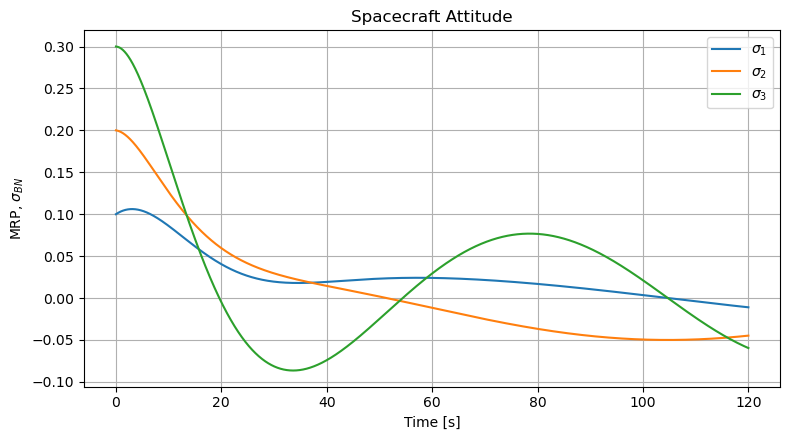

In [14]:
time = results["time"]

plt.figure(figsize=(8, 4.5))

plt.plot(time, results["sigma_BN"][:, 0], label=r"$\sigma_1$")
plt.plot(time, results["sigma_BN"][:, 1], label=r"$\sigma_2$")
plt.plot(time, results["sigma_BN"][:, 2], label=r"$\sigma_3$")

plt.xlabel("Time [s]")
plt.ylabel("MRP, $\\sigma_{BN}$")
plt.title("Spacecraft Attitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

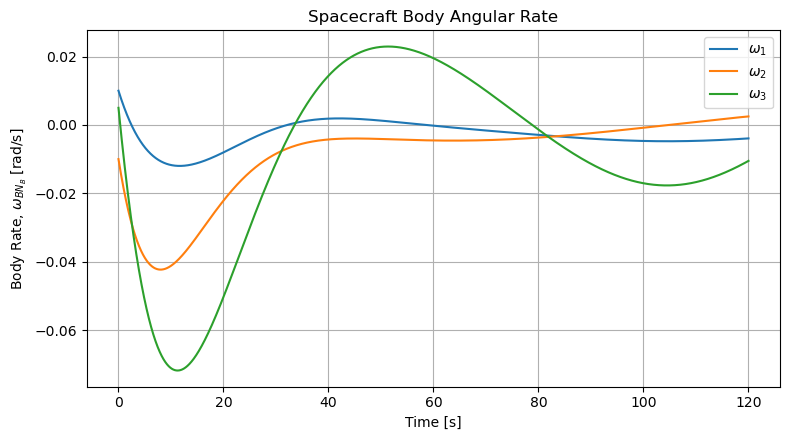

In [15]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["omega_BN_B"][:, 0], label=r"$\omega_1$")
plt.plot(time, results["omega_BN_B"][:, 1], label=r"$\omega_2$")
plt.plot(time, results["omega_BN_B"][:, 2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Body Rate, $\\omega_{BN_B}$ [rad/s]")
plt.title("Spacecraft Body Angular Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

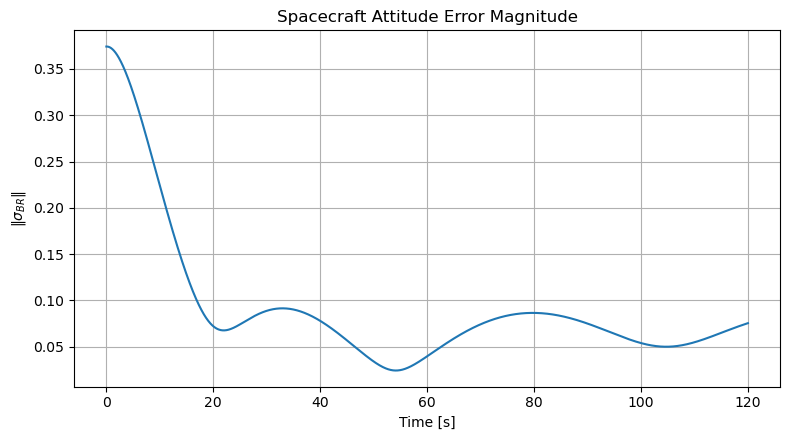

In [21]:
sigma_BR_norm = np.linalg.norm(results["sigma_BR"], axis=1)

plt.figure(figsize=(8, 4.5))

plt.plot(time, sigma_BR_norm)

#plt.yscale("log")

plt.xlabel("Time [s]")
plt.ylabel(r"$\|\sigma_{BR}\|$")
plt.title("Spacecraft Attitude Error Magnitude")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["omega_BR_B"][:, 0], label=r"$\omega_1$")
plt.plot(time, results["omega_BR_B"][:, 1], label=r"$\omega_2$")
plt.plot(time, results["omega_BR_B"][:, 2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Body Rate, $\\omega_{BN_B}$ [rad/s]")
plt.title("Spacecraft Body Angular Rate Error")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["u_s"][:, 0], label=r"$u_{s_1}$")
plt.plot(time, results["u_s"][:, 1], label=r"$u_{s_2}$")
plt.plot(time, results["u_s"][:, 2], label=r"$u_{s_3}$")
plt.plot(time, results["u_s"][:, 3], label=r"$u_{s_4}$")

plt.xlabel("Time [s]")
plt.ylabel(r"RW Motor Torque, $u_s$ [Nm]")
plt.title("Reaction Wheel Motor Torques")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["L_r"][:, 0], label=r"$L_{r_1}$")
plt.plot(time, results["L_r"][:, 1], label=r"$L_{r_2}$")
plt.plot(time, results["L_r"][:, 2], label=r"$L_{r_3}$")

plt.xlabel("Time [s]")
plt.ylabel(r"Control Torque, $L_r$ [Nm]")
plt.title("Requested Spacecraft Control Torque")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 1.2 - RW Configuration Considerations

## 1.3 - RW Torque Feedback Loop

## 1.4 - RW Speed Feedback Loop

# 2 - VSCMG Feedback Control